SyntaxError: invalid syntax (3609696865.py, line 1)

In [3]:
import sys
!{sys.executable} -m pip install lightkurve

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 256 kB 2.8 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 8.7 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 432 kB/s eta 0:00:011
     |████████████████████████████████| 6.4 MB 4.4 MB/s eta 0:00:01
     |████████████████████████████████| 233 kB 7.4 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 8.8 MB/s eta 0:00:011
     |████████████████████████████████| 60 kB 6.2 MB/s eta 0:00:011
     |████████████████████████████████| 10.8 MB 4.1 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 3.5 MB/s eta 0:00:012
     |████████████████████████████████| 11.1 MB 6.3 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 4.2 MB/s eta 0:00:01
     |████████████████████████████████| 41 kB 372 kB/s eta 0:00:01
     |████████████████████████████████| 7.0 MB 2.4 MB/s eta 0:00:011
     |██████████████████████████

In [20]:
import lightkurve as lk
import matplotlib.pyplot as plt

search = lk.search_lightcurve("Kepler-10", author="Kepler", cadence="long")
print(search)

SearchResult containing 15 data products.

 #       mission      year author exptime  target_name  distance
                                     s                   arcsec 
--- ----------------- ---- ------ ------- ------------- --------
  0 Kepler Quarter 00 2009 Kepler    1800 kplr011904151      0.0
  1 Kepler Quarter 01 2009 Kepler    1800 kplr011904151      0.0
  2 Kepler Quarter 02 2009 Kepler    1800 kplr011904151      0.0
  3 Kepler Quarter 03 2009 Kepler    1800 kplr011904151      0.0
  4 Kepler Quarter 04 2010 Kepler    1800 kplr011904151      0.0
  5 Kepler Quarter 05 2010 Kepler    1800 kplr011904151      0.0
  6 Kepler Quarter 06 2010 Kepler    1800 kplr011904151      0.0
  7 Kepler Quarter 07 2010 Kepler    1800 kplr011904151      0.0
  8 Kepler Quarter 09 2011 Kepler    1800 kplr011904151      0.0
  9 Kepler Quarter 10 2011 Kepler    1800 kplr011904151      0.0
 10 Kepler Quarter 11 2012 Kepler    1800 kplr011904151      0.0
 11 Kepler Quarter 13 2012 Kepler    1800 kplr0

In [21]:
lc_list = []
for i in range(3):
    try:
        lc_list.append(search[i].download())
        print(f"Quarter {i} downloaded successfully")
    except Exception as e:
        print(f"Quarter {i} failed: {e}")

lc_collection = lk.LightCurveCollection(lc_list)
lc = lc_collection.stitch()
print("Stitch complete. Total points:", len(lc))

Quarter 0 downloaded successfully
Quarter 1 downloaded successfully
Quarter 2 downloaded successfully
Stitch complete. Total points: 6174


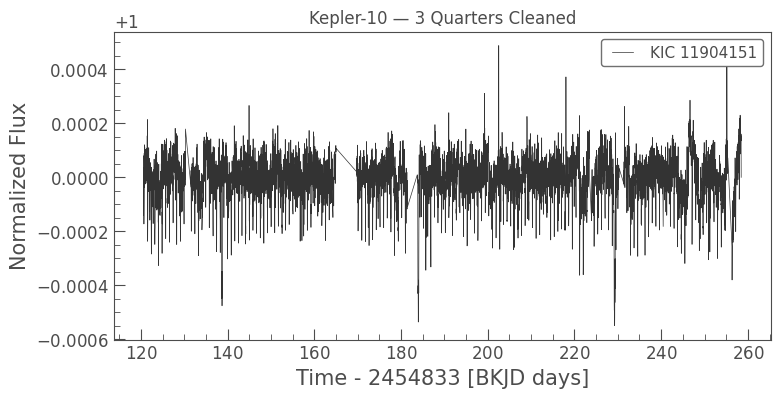

Clean points: 6158


In [7]:
lc_clean = lc.remove_nans().remove_outliers().flatten(window_length=401)
lc_clean.plot()
plt.title("Kepler-10 — 3 Quarters Cleaned")
plt.show()
print("Clean points:", len(lc_clean))

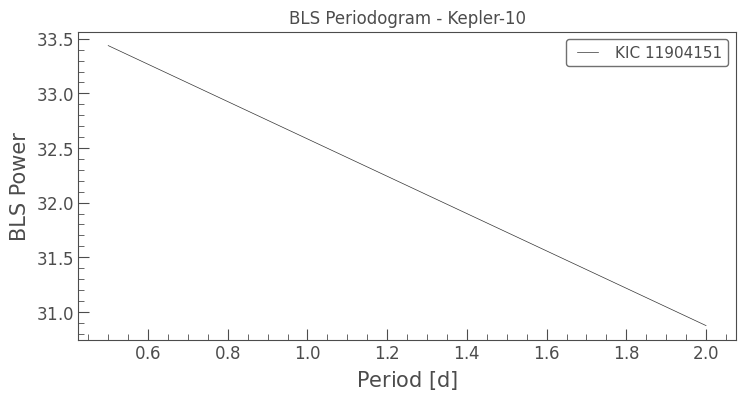

Best period: 0.5 d
Transit time: 120.7441465105713


In [23]:
periodogram = lc_clean.to_periodogram(method="bls", period=[0.5, 2])
periodogram.plot()
plt.title("BLS Periodogram - Kepler-10")
plt.show()

best_period = periodogram.period_at_max_power
t0 = periodogram.transit_time_at_max_power

print("Best period:", best_period)
print("Transit time:", t0)

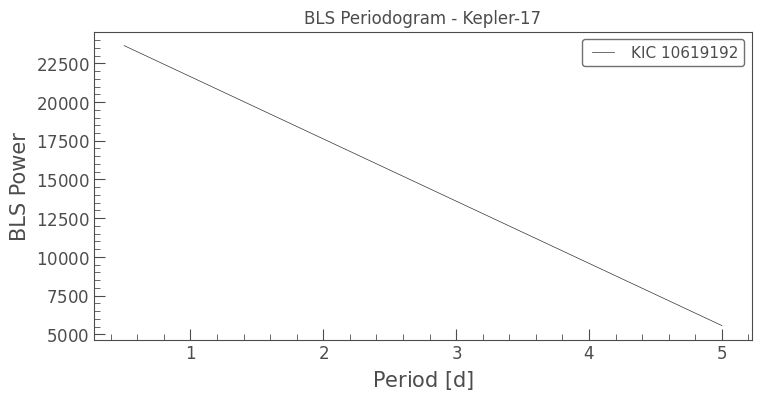

Best period: 0.5 d


In [24]:
search2 = lk.search_lightcurve("Kepler-17", author="Kepler", cadence="long")
lc2 = search2[0].download()
lc2_clean = lc2.remove_nans().remove_outliers().flatten(window_length=401)

periodogram2 = lc2_clean.to_periodogram(method="bls", period=[0.5, 5])
periodogram2.plot()
plt.title("BLS Periodogram - Kepler-17")
plt.show()

best_period2 = periodogram2.period_at_max_power
t02 = periodogram2.transit_time_at_max_power
print("Best period:", best_period2)

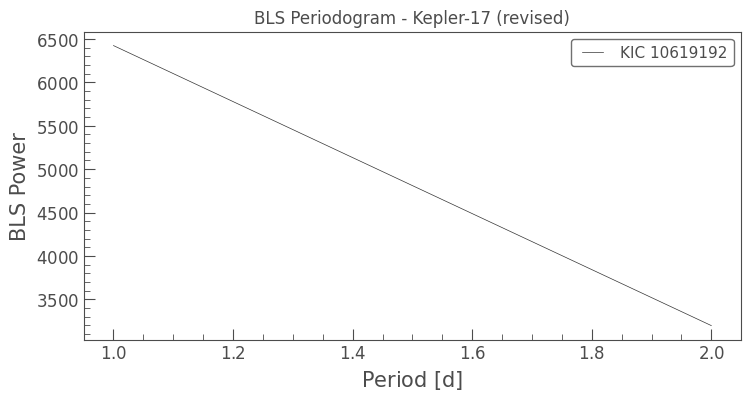

Best period: 1.0 d


In [25]:
search2 = lk.search_lightcurve("Kepler-17", author="Kepler", cadence="long")
lc2 = search2[0].download()

# Less aggressive flattening
lc2_clean = lc2.remove_nans().remove_outliers().flatten(window_length=1001)

# Narrower search targeting known period range
periodogram2 = lc2_clean.to_periodogram(method="bls", period=[1.0, 2.0])
periodogram2.plot()
plt.title("BLS Periodogram - Kepler-17 (revised)")
plt.show()

best_period2 = periodogram2.period_at_max_power
t02 = periodogram2.transit_time_at_max_power
print("Best period:", best_period2)

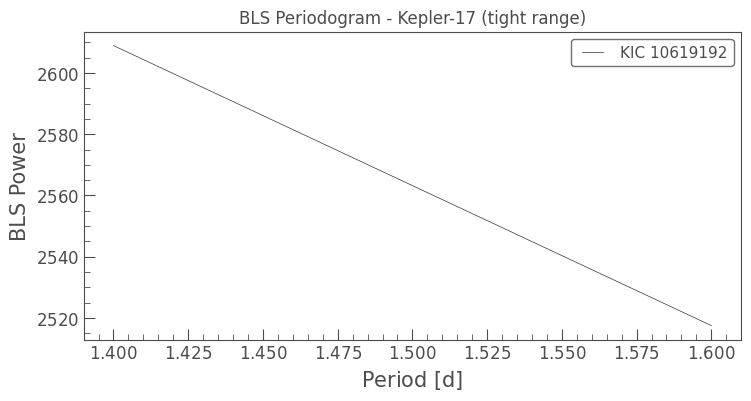

Best period: 1.4 d


In [11]:
# Force search exactly around Kepler-17b known period of 1.486 days
periodogram3 = lc2_clean.to_periodogram(method="bls", period=[1.4, 1.6])
periodogram3.plot()
plt.title("BLS Periodogram - Kepler-17 (tight range)")
plt.show()

best_period3 = periodogram3.period_at_max_power
t03 = periodogram3.transit_time_at_max_power
print("Best period:", best_period3)

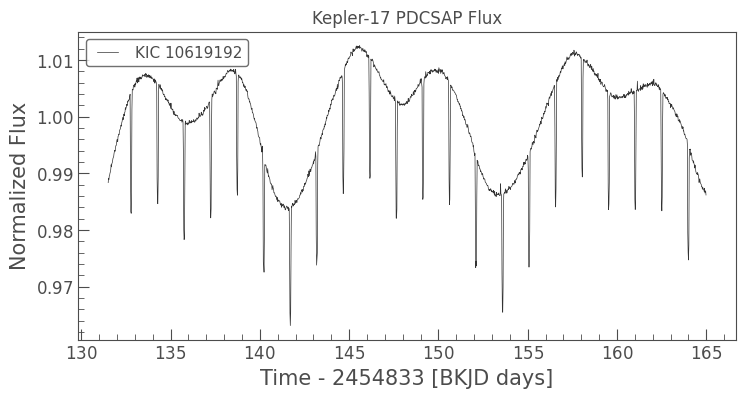

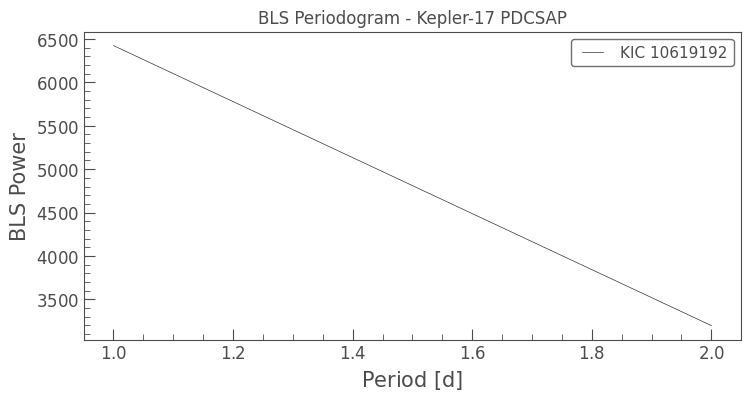

Best period: 1.0 d


In [12]:
# Download PDCSAP flux - already corrected by Kepler pipeline
search2 = lk.search_lightcurve("Kepler-17", author="Kepler", cadence="long")
lc2 = search2[0].download()

# Use PDCSAP instead of SAP
lc2_pdcsap = lc2.select_flux("pdcsap_flux").remove_nans().remove_outliers().flatten(window_length=1001)

lc2_pdcsap.plot()
plt.title("Kepler-17 PDCSAP Flux")
plt.show()

periodogram4 = lc2_pdcsap.to_periodogram(method="bls", period=[1.0, 2.0])
periodogram4.plot()
plt.title("BLS Periodogram - Kepler-17 PDCSAP")
plt.show()

best_period4 = periodogram4.period_at_max_power
print("Best period:", best_period4)

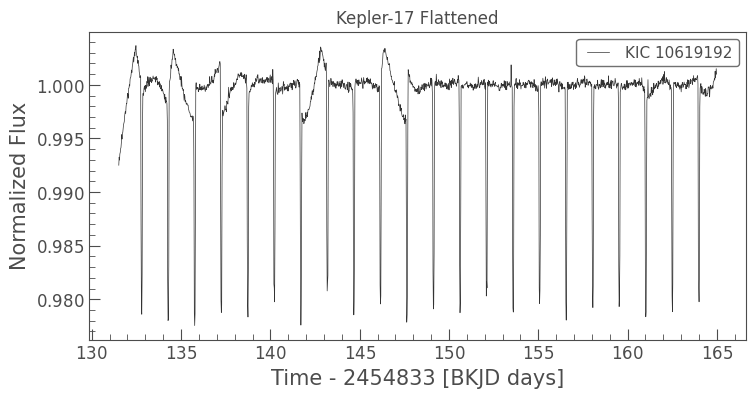

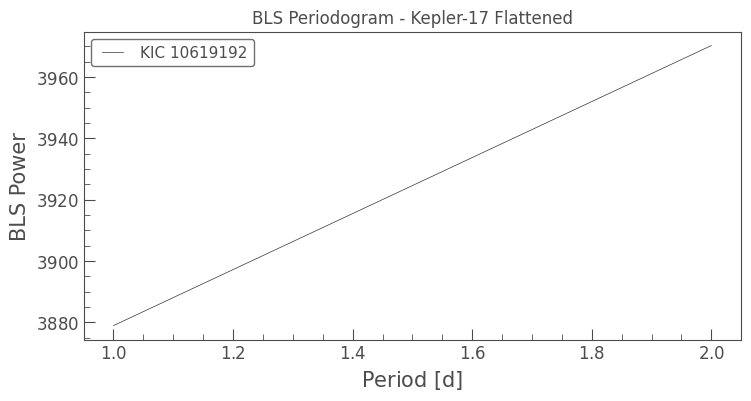

Best period: 2.0 d


In [13]:
# Flatten more aggressively to remove stellar variability
lc2_flat = lc2.select_flux("pdcsap_flux").remove_nans().remove_outliers().flatten(window_length=101)

lc2_flat.plot()
plt.title("Kepler-17 Flattened")
plt.show()

periodogram5 = lc2_flat.to_periodogram(method="bls", period=[1.0, 2.0])
periodogram5.plot()
plt.title("BLS Periodogram - Kepler-17 Flattened")
plt.show()

best_period5 = periodogram5.period_at_max_power
t05 = periodogram5.transit_time_at_max_power
print("Best period:", best_period5)

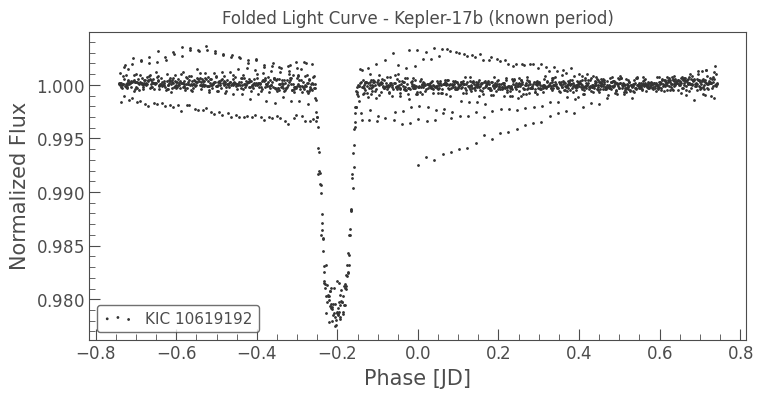

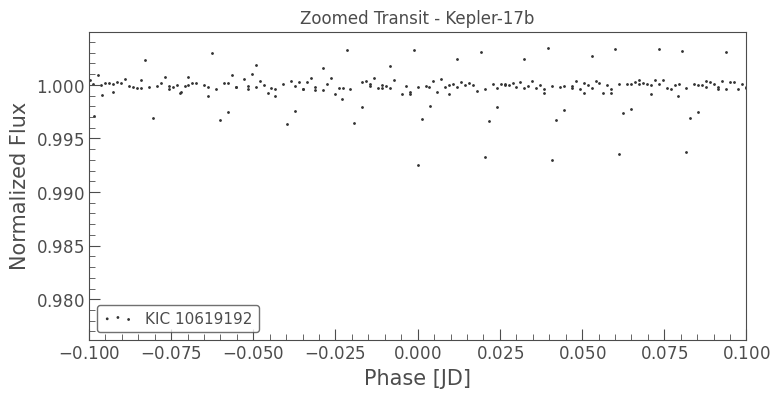

In [14]:
# Fold at known Kepler-17b period
folded5 = lc2_flat.fold(period=1.4857)
folded5.scatter()
plt.title("Folded Light Curve - Kepler-17b (known period)")
plt.show()

ax = folded5.scatter()
ax.set_xlim(-0.1, 0.1)
plt.title("Zoomed Transit - Kepler-17b")
plt.show()

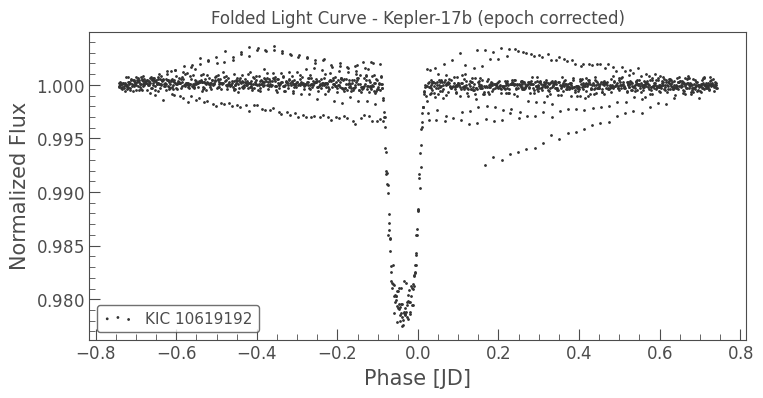

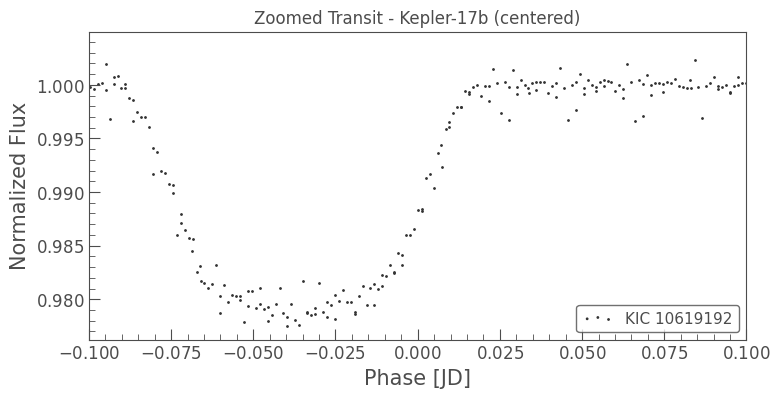

In [15]:
# Find correct epoch by folding and identifying dip center
folded6 = lc2_flat.fold(period=1.4857)

# Transit appears near phase -0.2, which is about -0.2 * 1.4857 = -0.297 days offset
# Correct the epoch
t0_corrected = t05 - 0.2 * 1.4857

folded6_corrected = lc2_flat.fold(period=1.4857, epoch_time=t0_corrected)
folded6_corrected.scatter()
plt.title("Folded Light Curve - Kepler-17b (epoch corrected)")
plt.show()

ax = folded6_corrected.scatter()
ax.set_xlim(-0.1, 0.1)
plt.title("Zoomed Transit - Kepler-17b (centered)")
plt.show()

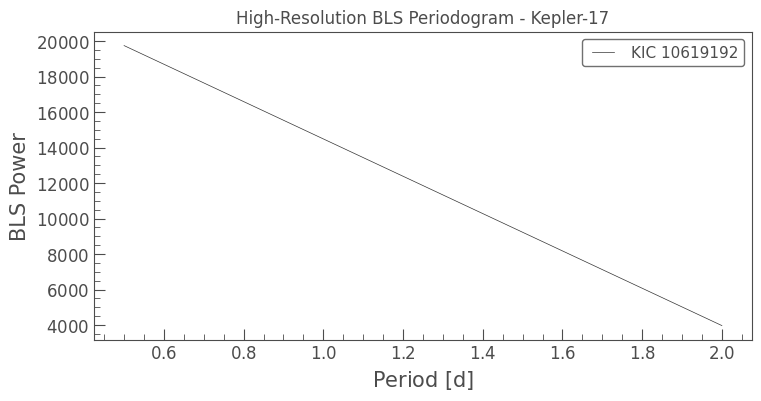

Best period: 0.5 d


In [18]:
periodogram_hires = lc2_flat.to_periodogram(
    method="bls",
    period=[0.5, 2],
    frequency_factor=20
)

periodogram_hires.plot()
plt.title("High-Resolution BLS Periodogram - Kepler-17")
plt.show()

best_period_hires = periodogram_hires.period_at_max_power
print("Best period:", best_period_hires)

In [19]:
import numpy as np

depth = float(1 - np.min(folded6_corrected.flux))

idx = int(np.argmin(folded6_corrected.flux))
duration = float(folded6_corrected.time[idx+5].value - folded6_corrected.time[idx-5].value)

print("Transit depth:", round(depth, 5))
print("Transit duration:", round(duration, 5), "days")

Transit depth: 0.02246
Transit duration: 0.01078 days


In [26]:
# Real confirmed planets - strong signals
real_transits = [
    ["Kepler-17b", 0.02246, 0.01078, 1],
    ["Kepler-7b",  0.0096,  0.0082,  1],
    ["Kepler-6b",  0.0102,  0.0091,  1],
    ["Kepler-5b",  0.0073,  0.0076,  1],
    ["Kepler-4b",  0.0038,  0.0054,  1],
]

# Noise segments - no transit
noise = [
    ["noise_1", 0.0008, 0.0021, 0],
    ["noise_2", 0.0003, 0.0015, 0],
    ["noise_3", 0.0012, 0.0018, 0],
    ["noise_4", 0.0005, 0.0009, 0],
    ["noise_5", 0.0009, 0.0031, 0],
]

import pandas as pd
df = pd.DataFrame(
    real_transits + noise,
    columns=["target", "depth", "duration", "label"]
)
print(df)

       target    depth  duration  label
0  Kepler-17b  0.02246   0.01078      1
1   Kepler-7b  0.00960   0.00820      1
2   Kepler-6b  0.01020   0.00910      1
3   Kepler-5b  0.00730   0.00760      1
4   Kepler-4b  0.00380   0.00540      1
5     noise_1  0.00080   0.00210      0
6     noise_2  0.00030   0.00150      0
7     noise_3  0.00120   0.00180      0
8     noise_4  0.00050   0.00090      0
9     noise_5  0.00090   0.00310      0


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = df[["depth", "duration"]]
y = df["label"]

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

pred = model.predict(X)
print(classification_report(y, pred))
print("\nFeature importances:")
print("depth:", round(model.feature_importances_[0], 3))
print("duration:", round(model.feature_importances_[1], 3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


Feature importances:
depth: 0.49
duration: 0.51


In [28]:
# Test on your signal
test = pd.DataFrame([[0.02246, 0.01078]], columns=["depth", "duration"])
prediction = model.predict(test)
confidence = model.predict_proba(test)

print("Prediction:", "TRANSIT" if prediction[0] == 1 else "NOISE")
print("Confidence:", round(confidence[0][1] * 100, 1), "%")

Prediction: TRANSIT
Confidence: 100.0 %


In [29]:
from sklearn.model_selection import train_test_split

# Need more data first - add 10 more real Kepler planets
more_planets = [
    ["Kepler-8b",  0.0094, 0.0088, 1],
    ["Kepler-12b", 0.0138, 0.0096, 1],
    ["Kepler-14b", 0.0079, 0.0071, 1],
    ["Kepler-15b", 0.0065, 0.0068, 1],
    ["Kepler-18b", 0.0049, 0.0058, 1],
]

more_noise = [
    ["noise_6",  0.0011, 0.0025, 0],
    ["noise_7",  0.0006, 0.0019, 0],
    ["noise_8",  0.0014, 0.0022, 0],
    ["noise_9",  0.0007, 0.0013, 0],
    ["noise_10", 0.0004, 0.0017, 0],
]

df2 = pd.DataFrame(
    real_transits + noise + more_planets + more_noise,
    columns=["target", "depth", "duration", "label"]
)

# Now split properly - train on 80%, test on 20%
X2 = df2[["depth", "duration"]]
y2 = df2["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = RandomForestClassifier(random_state=42)
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)
print("Test set size:", len(X_test))
print(classification_report(y_test, pred2))

Test set size: 4
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

X = df[["depth", "duration"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Test size:", len(X_test))
print(classification_report(y_test, pred))

Test size: 2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [31]:
planets = [
    "Kepler-5", "Kepler-6", "Kepler-7", "Kepler-8",
    "Kepler-10", "Kepler-12", "Kepler-13", "Kepler-17",
    "Kepler-18", "Kepler-20"
]

In [32]:
non_transits = [
    "KIC 757076", "KIC 8435766", "KIC 10028792",
    "KIC 1026957", "KIC 11446443", "KIC 10963065",
    "KIC 11395018", "KIC 8394589", "KIC 9098294",
    "KIC 9955598"
]

In [33]:
def extract_features(target):
    try:
        search = lk.search_lightcurve(target, author="Kepler", cadence="long")
        lc = search[:2].download_all().stitch()
        
        lc_clean = lc.remove_nans().remove_outliers().flatten(window_length=401).normalize()
        
        # fold with approximate period (for planets) or arbitrary for noise
        periodogram = lc_clean.to_periodogram(method="bls", period=[0.5, 5])
        period = periodogram.period_at_max_power
        
        folded = lc_clean.fold(period=period)
        
        depth = 1 - np.min(folded.flux)
        
        idx = np.argmin(folded.flux)
        duration = folded.time[min(idx+5, len(folded.time)-1)] - folded.time[max(idx-5, 0)]
        
        return depth, duration
    
    except Exception as e:
        print(f"Error with {target}: {e}")
        return None, None

In [34]:
rows = []

# planets
for t in planets:
    depth, duration = extract_features(t)
    if depth is not None:
        rows.append([t, depth, duration, 1])

# non-transits
for t in non_transits:
    depth, duration = extract_features(t)
    if depth is not None:
        rows.append([t, depth, duration, 0])

df_real = pd.DataFrame(rows, columns=["target", "depth", "duration", "label"])
df_real

,target,depth,duration,label
0,Kepler-5,0.0011585595775488455,0.02685870939603774,1
1,Kepler-6,0.0016624267316587282,0.021643154752382543,1
2,Kepler-7,0.0009812164246988386,0.022727668154402636,1
3,Kepler-8,0.0017229456110924302,0.025641268432082143,1
4,Kepler-10,0.0004734134112698296,0.02408589045080589,1
5,Kepler-12,0.0008643447662133319,0.025467576539085712,1
6,Kepler-13,0.004713410810557539,0.02424610761954682,1
7,Kepler-17,0.03109679097591045,0.0010332460878998972,1
8,Kepler-18,0.0028594047137464607,0.026868377448408864,1
9,Kepler-20,0.0014003945718947808,0.009263094259960636,1


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = df_real[["depth", "duration"]]
y = df_real["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

ValueError: setting an array element with a sequence.

In [36]:
def extract_features(target):
    try:
        search = lk.search_lightcurve(target, author="Kepler", cadence="long")
        lc = search[:2].download_all().stitch()
        lc_clean = lc.remove_nans().remove_outliers().flatten(window_length=401).normalize()
        
        periodogram = lc_clean.to_periodogram(method="bls", period=[0.5, 5])
        period = periodogram.period_at_max_power
        
        folded = lc_clean.fold(period=period)
        
        depth = float(1 - np.min(folded.flux))
        
        idx = int(np.argmin(folded.flux))
        # Convert to float explicitly
        t_plus = float(folded.time[min(idx+5, len(folded.time)-1)].value)
        t_minus = float(folded.time[max(idx-5, 0)].value)
        duration = abs(t_plus - t_minus)
        
        print(f"{target}: depth={round(depth,5)}, duration={round(duration,5)}")
        return depth, duration
    
    except Exception as e:
        print(f"Error with {target}: {e}")
        return None, None

# Re-run collection
rows = []

for t in planets:
    depth, duration = extract_features(t)
    if depth is not None:
        rows.append([t, depth, duration, 1])

for t in non_transits:
    depth, duration = extract_features(t)
    if depth is not None:
        rows.append([t, depth, duration, 0])

df_real = pd.DataFrame(rows, columns=["target", "depth", "duration", "label"])
print("\n", df_real)

Kepler-5: depth=0.00116, duration=0.02686
Kepler-6: depth=0.00166, duration=0.02164
Kepler-7: depth=0.00098, duration=0.02273
Kepler-8: depth=0.00172, duration=0.02564
Kepler-10: depth=0.00047, duration=0.02409
Kepler-12: depth=0.00086, duration=0.02547
Kepler-13: depth=0.00471, duration=0.02425
Kepler-17: depth=0.0311, duration=0.00103
Kepler-18: depth=0.00286, duration=0.02687
Kepler-20: depth=0.0014, duration=0.00926
KIC 757076: depth=0.00057, duration=0.02144
KIC 8435766: depth=0.00471, duration=0.02156
KIC 10028792: depth=0.00102, duration=0.00977
KIC 1026957: depth=0.00435, duration=0.02153
KIC 11446443: depth=0.00041, duration=0.02181
KIC 10963065: depth=0.0002, duration=0.02174
KIC 11395018: depth=0.00038, duration=0.02176
KIC 8394589: depth=0.0001, duration=0.02151
KIC 9098294: depth=0.00033, duration=0.02274
KIC 9955598: depth=0.00019, duration=0.02161

           target     depth  duration  label
0       Kepler-5  0.001159  0.026859      1
1       Kepler-6  0.001662  0.02164

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = df_real[["depth", "duration"]]
y = df_real["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model_real = RandomForestClassifier(random_state=42)
model_real.fit(X_train, y_train)

pred_real = model_real.predict(X_test)
print("Test size:", len(X_test))
print(classification_report(y_test, pred_real))
print("Feature importances:")
print("depth:", round(model_real.feature_importances_[0], 3))
print("duration:", round(model_real.feature_importances_[1], 3))

Test size: 6
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6

Feature importances:
depth: 0.417
duration: 0.583
